In [1]:
import pandas

data = pandas.read_csv("datasets/supermarket_data.csv")
data

,Invoice ID,city,customertype,gender,product,itemprice,quantity,total,date,time,payment,customersalary,rating
0,750-67-8428,Nairobi,Member,Female,Health and beauty,74.69,7,548.9715,1/5/2019,13:08,MPESA,26.1415,9.1
1,226-31-3081,Nakuru,Normal,Female,Electronic accessories,15.28,5,80.2200,3/8/2019,10:29,Cash,3.8200,9.6
2,631-41-3108,Nairobi,Normal,Female,Home and lifestyle,46.33,7,340.5255,3/3/2019,13:23,Credit card,16.2155,7.4
3,123-19-1176,Nairobi,Member,Female,Health and beauty,58.22,8,489.0480,1/27/2019,20:33,MPESA,23.2880,8.4
4,373-73-7910,Nairobi,Normal,Female,Health and beauty,86.31,7,634.3785,2/8/2019,10:37,MPESA,30.2085,5.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
996,233-67-5758,Nakuru,Normal,Male,Health and beauty,40.35,1,42.3675,1/29/2019,13:46,MPESA,2.0175,6.2
997,303-96-2227,Mombasa,Normal,Female,Home and lifestyle,97.38,10,1022.4900,3/2/2019,17:16,MPESA,48.6900,4.4
998,727-02-1313,Nairobi,Member,Male,Food and beverages,31.84,1,33.4320,2/9/2019,13:22,Cash,1.5920,7.7
999,347-56-2442,Nairobi,Normal,Male,Home and lifestyle,65.82,1,69.1110,2/22/2019,15:33,Cash,3.2910,4.1


In [2]:
# Use the Describe function
data.describe()

,itemprice,quantity,total,customersalary,rating
count,998.000000,1001.000000,1001.000000,1001.000000,1001.000000
mean,55.686523,5.505495,322.739927,15.368568,6.972527
std,26.538665,2.925444,245.867115,11.707958,1.717729
min,10.080000,1.000000,10.678500,0.508500,4.000000
25%,32.825000,3.000000,122.524500,5.834500,5.500000
50%,55.230000,5.000000,253.680000,12.080000,7.000000
75%,78.040000,8.000000,471.030000,22.430000,8.500000
max,99.960000,10.000000,1042.650000,49.650000,10.000000


In [3]:
# We have noticed that the itme price column, contains 3 empty slots.
# We need to fill these empty slots with a value and in this case we shall fill with the mean of the column.

data["itemprice"] = data["itemprice"].fillna(55)

# describe the data again
data.describe()

,itemprice,quantity,total,customersalary,rating
count,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000
mean,55.684466,5.505495,322.739927,15.368568,6.972527
std,26.498854,2.925444,245.867115,11.707958,1.717729
min,10.080000,1.000000,10.678500,0.508500,4.000000
25%,32.900000,3.000000,122.524500,5.834500,5.500000
50%,55.040000,5.000000,253.680000,12.080000,7.000000
75%,77.950000,8.000000,471.030000,22.430000,8.500000
max,99.960000,10.000000,1042.650000,49.650000,10.000000


In [4]:
# Get the number of entries in a given column
data.groupby("gender").size()

gender
Female    625
Male      376
dtype: int64

In [5]:
# Combine multiple columns
data.groupby(["city", "payment"]).size()

city     payment    
Mombasa  Cash            73
         Credit card     83
         MPESA          144
Nairobi  Cash           118
         Credit card     98
         MPESA          179
Nakuru   Cash            84
         Credit card     74
         MPESA          148
dtype: int64

In [6]:
# Import the modules
import seaborn as sns
import matplotlib.pyplot as plt

C:\Users\PC\AppData\Local\Temp\ipykernel_16212\3661246918.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x= "gender", data=data, palette="spring")


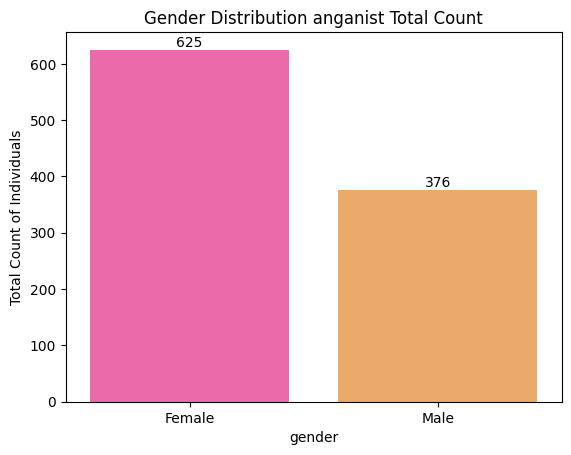

In [7]:
# Below is a count plot showing the distribution of males to females

ax = sns.countplot(x= "gender", data=data, palette="spring")
plt.title("Gender Distribution anganist Total Count")
plt.ylabel("Total Count of Individuals")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'Health and beauty'),
  Text(1, 0, 'Electronic accessories'),
  Text(2, 0, 'Home and lifestyle'),
  Text(3, 0, 'Food and beverages'),
  Text(4, 0, 'Sports and travel'),
  Text(5, 0, 'Fashion accessories')])

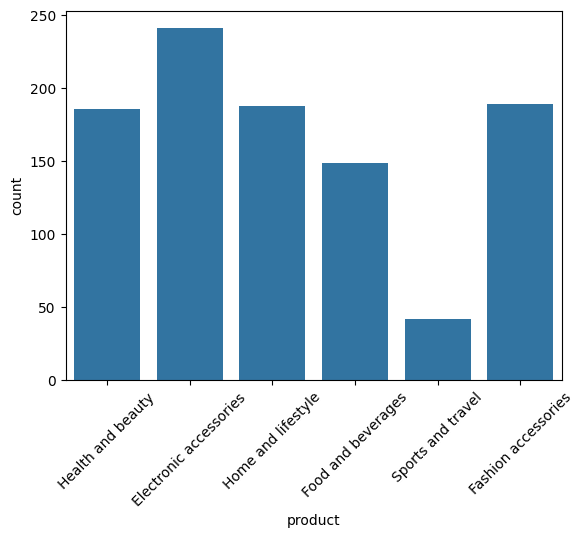

In [8]:
# Class Work : Create a Count Plot of products
# Which product category appears the most?
sns.countplot(x= "product", data=data)
plt.xticks(rotation = 45)


<Axes: xlabel='gender', ylabel='count'>

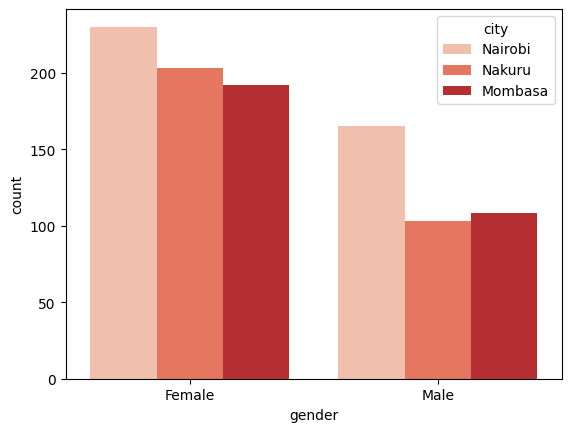

In [9]:
# Below is a countplot that has two coloumns
sns.countplot(x="gender", hue="city", palette="Reds", data=data)

<Axes: >

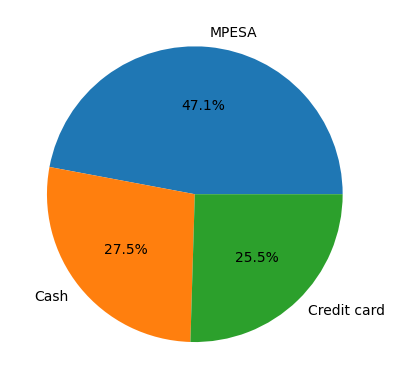

In [10]:
# below is a pieplot
data["payment"].value_counts().plot.pie(autopct='%1.1f%%')